Este script:  
  
Realiza a coleta dos dados de interesse para análise. Os dados são exportados e ficam disponíveis para download na seção de arquivos do notebook.  


Ajustes e primeiras análises exploratórias;  

Conclusões de BI.  

Teste de modelo ARIMA para previsão do comportamento das variáveis.  

Conclusão do modelo testado.  



# Bibliotecas

In [104]:
import pandas as pd
import numpy as np
import requests, zipfile, io
# --- Etapa de BI ---#
import seaborn as sns
import matplotlib.pyplot as plt
!pip install plotly
import plotly.express as px
import os
import plotly.graph_objects as go
import plotly.subplots as sp
#--- Etapa de Analytics ---#
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.vector_ar.vecm import VECM
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Coleta e Armazenamento

### Download nº 1:
**Nome:** Inadimplência da carteira de crédito - Total  
**Descrição:** Série histórica das taxas de inadimplência mensais no Brasil para pessoas físicas e jurídicas desde 2011.  
**Fonte:** Banco Central dos Brasil

In [105]:
url_bcb = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.21082/dados?formato=csv"
df_inadimplencia = pd.read_csv(url_bcb, sep=';')

In [106]:
df_inadimplencia['valor'] = df_inadimplencia['valor'].str.replace(',', '.').astype(float)

In [107]:
df_inadimplencia['data'] = pd.to_datetime(df_inadimplencia['data'], format='%d/%m/%Y')

In [108]:
df_inadimplencia = df_inadimplencia.rename(columns={'valor': 'txa_inadimplencia'})

In [109]:
df_inadimplencia.head(3)

,data,txa_inadimplencia
0,2011-03-01,3.17
1,2011-04-01,3.24
2,2011-05-01,3.37


Exportar df_inadimplencia MENSAL:

In [110]:
# Exportação do df_inadimplencia em formato mensal
df_inadimplencia.to_csv("df_inadimplencia_mensal.csv", index=False)

A partir desta célula o df passará a ser trimestral, para fins de análises conjuntas com outras variáveis que usam apenas essa configuração de tempo.

In [111]:
df_inadimplencia['trimestre'] = df_inadimplencia['data'].dt.to_period('Q')

In [112]:
# Média dos dados mensal para trimestral
df_inadimplencia_trimestral = (
    df_inadimplencia
    .groupby('trimestre', as_index=False)
    .agg(media_inadimplencia=('txa_inadimplencia', 'mean'))
)

df_inadimplencia_trimestral['trimestre'] = df_inadimplencia_trimestral['trimestre'].astype(str)

In [113]:
df_inadimplencia_trimestral.head(3)

,trimestre,media_inadimplencia
0,2011Q1,3.170000
1,2011Q2,3.310000
2,2011Q3,3.443333


### Download 2
**Nome:** Tabela 6691 - IPCA - Série histórica com número-índice, variação mensal e variações acumuladas a partir de 12 meses (a partir de novembro/2014)

**Parâmetros:**  
* Variável = IPCA - Variação mensal (%)  
* Mês = todas as caixas de seleção  
* Unidade Territorial = Brasil

**Fonte:** https://sidra.ibge.gov.br/Tabela/6691

In [114]:
url_ipca = "https://apisidra.ibge.gov.br/values/t/6691/n1/all/v/63/p/all/d/v63%202"
df_ipca = pd.read_json(url_ipca)

In [115]:
# Seleção das colunas de interesse
df_ipca = df_ipca[['V','D3C']]

In [116]:
# Ajuste do cabeçalho
df_ipca.columns = df_ipca.iloc[0]
df_ipca = df_ipca.drop(0).reset_index(drop=True)

In [117]:
# Converter coluna 'Valor' para float
df_ipca['Valor'] = df_ipca['Valor'].astype(float)
df_ipca = df_ipca.rename(columns={'Valor': 'txa_variacao_ipca'})
# E coluna 'Mês (Código)' para datetime
df_ipca['Mês (Código)'] = pd.to_datetime(df_ipca['Mês (Código)'], format='%Y%m')

In [118]:
df_ipca.head()

,txa_variacao_ipca,Mês (Código)
0,0.51,2014-11-01
1,0.78,2014-12-01
2,1.24,2015-01-01
3,1.22,2015-02-01
4,1.32,2015-03-01


Exportar df_ipca MENSAL:

In [119]:
# Exportação do df_ipca em formato mensal
df_ipca.to_csv("df_ipca_mensal.csv", index=False)

A partir desta célula o df passará a ser trimestral, para fins de análises conjuntas com outras variáveis que usam apenas essa configuração de tempo.

In [120]:
# Criação da coluna trimestre
df_ipca['trimestre'] = df_ipca['Mês (Código)'].dt.to_period('Q')

# Média dos dados mensal para trimestral
df_ipca_trimestral = (
    df_ipca
    .groupby('trimestre', as_index=False)
    .agg(media_ipca=('txa_variacao_ipca', 'mean'))
)

In [121]:
df_ipca_trimestral['trimestre'] = df_ipca_trimestral['trimestre'].astype(str)

In [122]:
df_ipca_trimestral.head(3)

,trimestre,media_ipca
0,2014Q4,0.645000
1,2015Q1,1.260000
2,2015Q2,0.746667


### Download 3:  
**Nome:** Tabela 4093 - Pessoas de 14 anos ou mais de idade, total, na força de trabalho, ocupadas, desocupadas, fora da força de trabalho, em situação de informalidade e respectivas taxas e níveis, por sexo  
**Parâmetros:**  
* Variáveis: Pessoas de 14 anos ou mais de idade, na força de trabalho, na semana de referência (Mil pessoas), Pessoas de 14 anos ou mais de idade ocupadas na semana de referência (Mil pessoas) e Pessoas de 14 anos ou mais de idade, desocupadas na semana de referência (Mil pessoas).  
* Sexo = Total  
* Trimestre = todas as caixas de seleção  
* Unidade Territorial = Brasil  

**Descrição:** Quantidade de pessoas na força de trabalho, ocupadas e desocupadas.  

**Fonte:** IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral (https://sidra.ibge.gov.br/tabela/4093)

In [123]:
# Download
url_forcaDeTrabalho = "https://apisidra.ibge.gov.br/values/t/4093/n1/all/v/4088,4090,4092/p/all/c2/6794"
df_ft = pd.read_json(url_forcaDeTrabalho)

In [124]:
# Seleção das colunas de interesse
df_ft = df_ft[['V', 'D2C', 'D3C']]

In [125]:
# Ajuste do cabeçalho
df_ft.columns = df_ft.iloc[0]
df_ft = df_ft.drop(0).reset_index(drop=True)

In [126]:
# Converter 'Valor' para inteiro
df_ft['Valor'] = df_ft['Valor'].astype(int)

# Substituir os códigos numéricos por descrições intuitivas
mapa_variaveis = {
    '4088': 'Forca de Trabalho',      # Força de Trabalho
    '4090': 'Ocupados',               # Ocupados
    '4092': 'Desocupados'             # Desocupados
}

df_ft['Variável (Código)'] = df_ft['Variável (Código)'].map(mapa_variaveis)

In [127]:
# Calcular percentual de desocupados

# pivotar para ter cada variável como coluna:
df_desocupados = df_ft.pivot_table(
    index='Trimestre (Código)',
    columns='Variável (Código)',
    values='Valor',
    aggfunc='sum'
).reset_index()

# criar a coluna com o cálculo de percentual de desocupados
df_desocupados['taxa_desocupados'] = (df_desocupados['Desocupados'] / df_desocupados['Forca de Trabalho']) * 100
df_desocupados['taxa_desocupados'] = df_desocupados['taxa_desocupados'].round(2)

In [128]:
# Padronização da escrita do trimestre
df_desocupados['Trimestre (Código)'] = (
    df_desocupados['Trimestre (Código)'].astype(str)
    .str[:4] + 'Q' +
    df_desocupados['Trimestre (Código)'].astype(str).str[-2:].astype(int).astype(str)
)

In [129]:
df_desocupados = df_desocupados.rename(columns={'Trimestre (Código)': 'trimestre'})

In [130]:
df_desocupados.drop(['Desocupados', 'Forca de Trabalho', 'Ocupados'], axis=1, inplace=True)

In [131]:
df_desocupados.head(3)

Variável (Código),trimestre,taxa_desocupados
0,2012Q1,7.99
1,2012Q2,7.57
2,2012Q3,7.12


In [132]:
# Exportação do df
df_desocupados.to_csv("df_desocupados_trimestral.csv", index=False)

### Download 4:
**Nome:** Tabela 5932 - Taxa de variação do índice de volume trimestral  
**Descrição:**  
* Variável = Taxa acumulada em quatro trimestres (em relação ao mesmo período do ano anterior) (%): 1 de 1 casas decimais
* Setores e subsetores = PIB a preços de mercado
* Trimestre = Todas as caixas de seleção  
* Unidade Territorial = Brasil  

**Fonte:** https://sidra.ibge.gov.br/Tabela/5932

In [133]:
url_pib = "https://apisidra.ibge.gov.br/values/t/5932/n1/all/v/6562/p/all/c11255/90707/d/v6562%201"
df_pib = pd.read_json(url_pib)

In [134]:
# Manter apenas colunas relevantes
df_pib = df_pib[['D3C', 'V']]

In [135]:
# Ajuste do cabeçalho
df_pib.columns = df_pib.iloc[0]
df_pib = df_pib.drop(0).reset_index(drop=True)

In [136]:
# Converter coluna 'Valor' para float
df_pib['Valor'] = df_pib['Valor'].astype(float)
df_pib = df_pib.rename(columns={'Valor': 'txa_variacao_pib'})

In [137]:
# Padronização das colunas trimestrais com os dfs anteriores
df_pib['Trimestre (Código)'] = (
    df_pib['Trimestre (Código)'].astype(str)
    .str[:4] + 'Q' +
    df_pib['Trimestre (Código)'].astype(str).str[-2:].astype(int).astype(str)
)

In [138]:
df_pib.rename(columns={'Trimestre (Código)': 'trimestre'}, inplace=True)

In [139]:
df_pib.head(3)

,trimestre,txa_variacao_pib
0,1996Q1,2.5
1,1996Q2,2.1
2,1996Q3,2.3


In [140]:
# Exportação do df
df_pib.to_csv("df_pib_trimestral.csv", index=False)

### União dos conjuntos de dados

In [141]:
cd_final_trimestral = df_pib \
    .merge(df_inadimplencia_trimestral, on='trimestre', how='inner') \
    .merge(df_desocupados, on='trimestre', how='inner') \
    .merge(df_ipca_trimestral, on='trimestre', how='inner')

In [142]:
cd_final_trimestral.head(3)

,trimestre,txa_variacao_pib,media_inadimplencia,taxa_desocupados,media_ipca
0,2014Q4,0.5,2.846667,6.56,0.645000
1,2015Q1,-0.7,2.830000,8.02,1.260000
2,2015Q2,-1.3,2.966667,8.41,0.746667


### Exportar df_final

In [143]:
cd_final_trimestral.to_excel("Conjunto Final Unificado - Trimestral.xlsx", index=False)

In [144]:
cd_final_trimestral.to_csv("Conjunto Final Unificado - Trimestral.csv", index=False)

# Análises

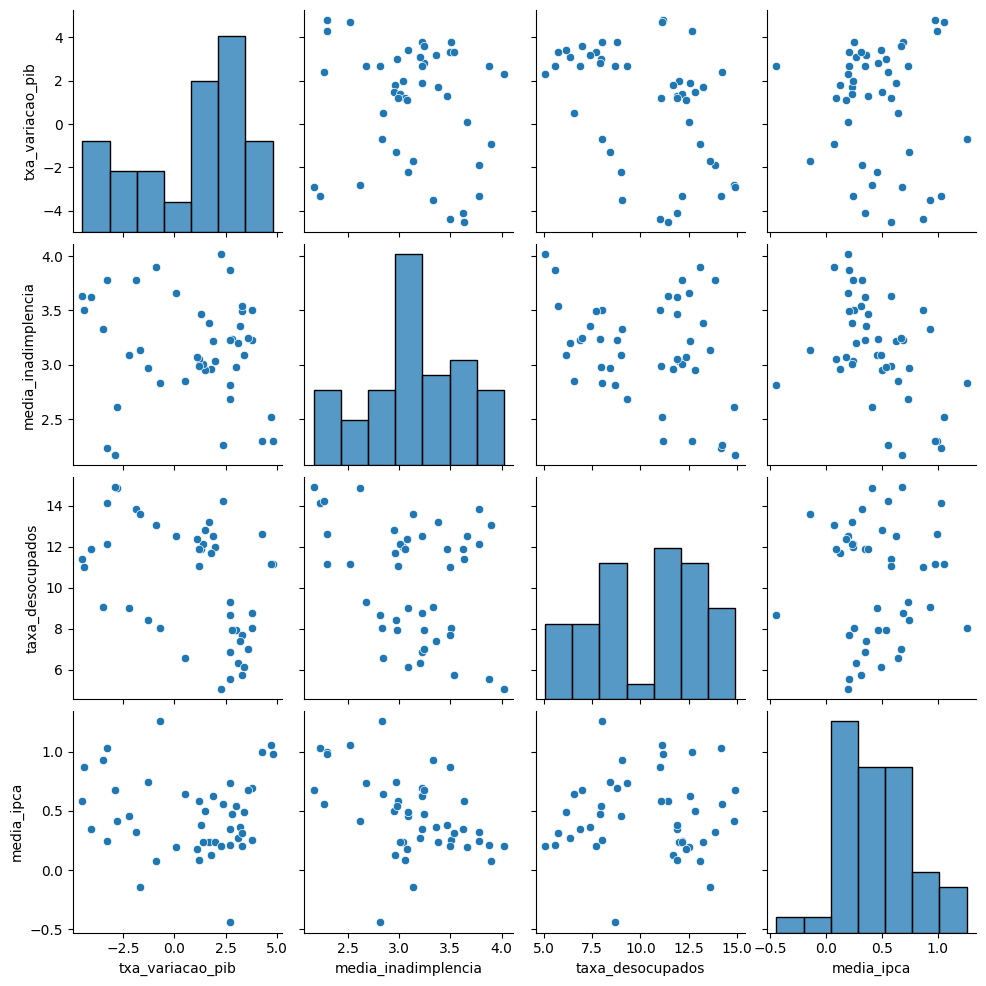

In [145]:
# Verificar se há linearidade
sns.pairplot(cd_final_trimestral)
plt.show()

Nao indica relação linear forte (linha reta mais definida)

In [146]:
# Definição de variáveis (dependentes e independentes)
X = cd_final_trimestral[['txa_variacao_pib', 'taxa_desocupados', 'media_ipca']]
y = cd_final_trimestral['media_inadimplencia']

# Criação do modelo
modelo_rl = LinearRegression()

# Ajuste do modelo
modelo_rl.fit(X, y)

# Previsões
y_pred = modelo_rl.predict(X)

# Calcular R²
r2_total = r2_score(y, y_pred)

print(f"R² analisando o conjunto de variáveis: {r2_total:.4f}")

# Cada variável avaliada separadamente:
print('\nR² analisando cada variável individualmente')
for col in X.columns:
    X_single = cd_final_trimestral[[col]]

    modelo_rl.fit(X_single, y)
    y_pred = modelo_rl.predict(X_single)

    r2_individual = r2_score(y, y_pred)

    print(f"{col}: R² = {r2_individual:.4f}")

R² analisando o conjunto de variáveis: 0.4545

R² analisando cada variável individualmente
txa_variacao_pib: R² = 0.0226
taxa_desocupados: R² = 0.1060
media_ipca: R² = 0.2197


Isso demonstra para explicar a inadimplencia ajuda mais analisar: **conjunto x inadimplência** do que avaliar apenas **uma_variável x inadimplencia**.

In [147]:
corr_spearman = cd_final_trimestral.select_dtypes(include='number').corr(method='spearman')
corr_spearman['media_inadimplencia'].sort_values(ascending=False)

,media_inadimplencia
media_inadimplencia,1.000000
txa_variacao_pib,-0.132274
taxa_desocupados,-0.268191
media_ipca,-0.466140


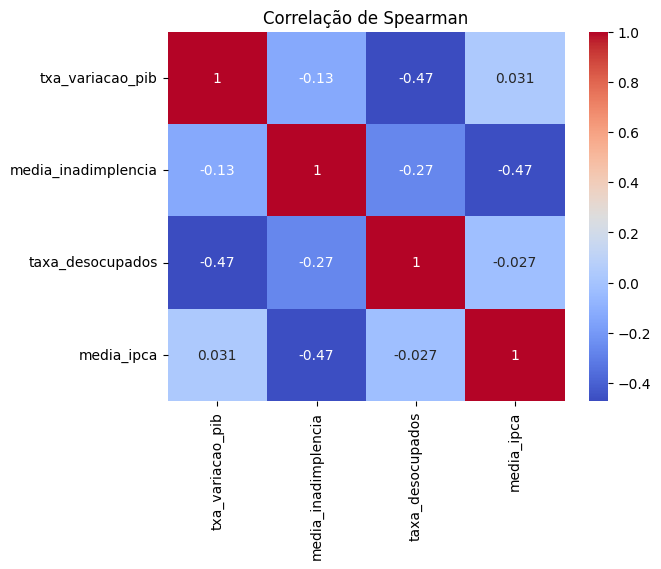

In [148]:
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm')
plt.title("Correlação de Spearman")
plt.show()

Segundo a correlação de Spearman há uma correlação monotônica NEGATIVA entre a inadimplência e as demais variáveis.  
Forças:  
ipca = -0.47 (Moderada)  
desemprego = -0.27 (Fraca)   
pib = -0.13 (Muito fraca)  

Quando essas variáveis caem, a inadimplencia tende a subir.


---

Resultado contraintuitivo:   
Importante ressaltar que Spearman não trata defasagem temporal, o que provavelmente ocorre nesses dados. Por exemplo: Inflação sobe em um mês, e a inadimplência sobe apenas depois de alguns trimestres.


---
As defasagens são fundamentais para modelar comportamentos dinâmicos, prever demandas e entender relações de causa e efeito que não são imediatas. Por isso, vamos trabalhar modelos que considerem defasagens (lags).


In [149]:
df = cd_final_trimestral.copy()

# Criação de lags das variáveis explicativas para 1 e 2 trimestres
for col in ['media_ipca', 'taxa_desocupados', 'txa_variacao_pib']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

# Lag da variável alvo:
df['inad_lag1'] = df['media_inadimplencia'].shift(1)
# Remoção de valores nulos que normalmente surgem da  criação de lags
df = df.dropna()

In [150]:
# Denfinir as variáveis:
X = df[[
    'inad_lag1','media_ipca_lag1', 'media_ipca_lag2',
    'taxa_desocupados_lag1', 'taxa_desocupados_lag2',
    'txa_variacao_pib_lag1', 'txa_variacao_pib_lag2'
]]

y = df['media_inadimplencia']

In [151]:
# Para série temporal, não se usa separação aleatória de treino e teste
# Usa-se a ordem temporal

split = int(len(df) * 0.7)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [152]:
# Testando a regressão Linear agora com as lags
modelo_rl_lags = LinearRegression()
modelo_rl_lags.fit(X_train, y_train)

#Resultados de R² e coeficientes:
print("R² treino:", modelo_rl_lags.score(X_train, y_train))
print("R² teste:", modelo_rl_lags.score(X_test, y_test))

coef = pd.Series(modelo_rl_lags.coef_, index=X.columns)
print('\nQuais variáveis influenciam e com quais defasagens:')
print(coef.sort_values(ascending=False))

R² treino: 0.9548403869431407
R² teste: 0.6251931139474987

Quais variáveis influenciam e com quais defasagens:
inad_lag1                0.972827
media_ipca_lag2          0.147750
media_ipca_lag1          0.094382
txa_variacao_pib_lag1    0.045857
taxa_desocupados_lag2   -0.024992
taxa_desocupados_lag1   -0.026719
txa_variacao_pib_lag2   -0.048416
dtype: float64


In [153]:
df.select_dtypes(include='number') \
  .corr(method='spearman')['media_inadimplencia'] \
  .sort_values()

,media_inadimplencia
taxa_desocupados_lag2,-0.489146
media_ipca,-0.427816
taxa_desocupados_lag1,-0.406690
taxa_desocupados,-0.317967
media_ipca_lag1,-0.243431
txa_variacao_pib,-0.161895
txa_variacao_pib_lag1,-0.108408
media_ipca_lag2,-0.096043
txa_variacao_pib_lag2,-0.095921
inad_lag1,0.915131


Os dados mostram que a inadimplência é bastante dependente do próprio passado:  
* Regressão Linear Múltivariada (inad_lag1) = 0.97 na regressão linear múltipla;  
* Correlação de Spearman = 0.91  

IPCA:  
O efeito da inflação (nesse caso avaliada apenas pelo IPCA) é positivo e demora de 1 a 2 trimestres para aparecer na inadimplência (coeficientes do modelo_rl = +0.094 e +0.147).  

DESEMPREGO:  
coeficientes negativos e pequenos (~0.02) no do modelo de regressão linear (modelo_rl) e -0.48 na correlação Spearman. É uma contradição que pode indicar uma relação instável, mediada por outras variáveis ou não linear.  

PIB:  
Relação uase irrelevante com a variável inadimplência.  

---
Quando o modelo foi treinado sem a lag da inadimplencia o modelo de RL falha terrivelmente (R² treino: 0.6157719040441174 / R² teste: -4.006134352125788). O que pode indicar:  
* A inadimplência é altamente dominada pela sua própria dinâmica passada (processo autorregressivo)  
* A inadimplência hoje deve ser analisada por sua própria trajetória passada + variáveis macroeconômicas  


---
Para finalizar o modelo será testado usando apenas a lag (inércia) da inadimplência, sem as demais variáveis:





In [154]:
# Teste do modelo APENAS com a inércia da inadimplência:
X_com_inercia = df[['inad_lag1']]
y = df['media_inadimplencia']

split = int(len(df) * 0.7)
X_train, X_test = X_com_inercia.iloc[:split], X_com_inercia.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

modelo_rl_apenasInercia = LinearRegression()
modelo_rl_apenasInercia.fit(X_train, y_train)

print("R² treino:", modelo_rl_apenasInercia.score(X_train, y_train))
print("R² teste:", modelo_rl_apenasInercia.score(X_test, y_test))
print("Coeficiente:", modelo_rl_apenasInercia.coef_[0])

R² treino: 0.8813608046147009
R² teste: 0.5433345108324772
Coeficiente: 0.9391913796555791




| COMPARAÇÃO DOS MODELOS                  | R² teste |
| ----------------------- | -------- |
| Só inércia (inad_lag1)              | **0.54** |
| Completo (com demais variáveis e lags) | **0.62** |  

A maior parte da explicação do comportamento da inadimplência vem dela mesma (cerca de 90%) o restante pode ser incrementado por demais variáveis econômicas.  
Sobre o coeficiente do modelo que avaliou apenas a inercia da inadimplencia (~0.94): significa que se a inadimplência sobe 1 hoje tende a subir aproximadamente 0.94 no próximo período.

# Conclusão sobra a fase exploratória:  
Para avaliar o comportamento da inadimplência precisamos:  
* 1- Considerar o conjunto de variáveis: Pois não há apenas uma variável que tenha grande impacto sozinha no comportamento da inadimplência.  
* 2- Considerar as defasagens temporais. Pois um impacto no IPCA tende a demorar 1 a 2 períodos para impactar a inadimplência.
   
Com relação às hipóteses da fase 1 do projeto:  

* **Hipótese 1:** Existe relação positiva entre a taxa de desemprego e os níveis de inadimplência.  

Não. Tanto Correlação de Spearman quanto modelo de regressão logística demonstram relação negativa.  

* **Hipótese 2:** A variação da taxa de desemprego pode anteceder mudanças nos índices de inadimplência.  

Não de forma consistente.  
O desemprego passado tem uma relação mais forte com a inadimplência do que o atual (Spearman com defasagens: taxa_desocupados_lag2 -0.489146 e taxa_desocupados_lag1 -0.406690), ainda assim, no modelo de regressão logística seus coeficiente são pouco relevantes.

* **Hipótese 3:** A análise de dados históricos utilizando ferramentas de Business Intelligence permite identificar padrões e tendências entre as variáveis analisadas.  
Sim.  
Sem a análise estruturada padrões relevantes e não triviais não teriam aparecido. Por exemplo:
  * O padrão temporal é forte (inad_lag1 no modelo modelo_rl_apenasInercia = 0.939 e Spearman com defasagem inad_lag1 0.915).  
  * Importância de considerar as defasagens na análise dos dados (modelo sem lag R² = -4).  
  * Spearman x Regressão logística obtiveram alguns sinais diferentes, indicando a necessidade de múltiplas abordagens.




# História dos dados: Dinâmica da inadimplência

**1 - A inadimplência tem memória**   
A inadimplência atual depende fortemente da anterior (quase linear)

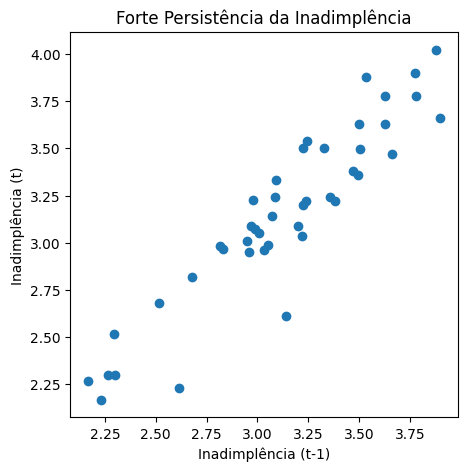

In [155]:
plt.figure(figsize=(5, 5))
plt.scatter(df['inad_lag1'], df['media_inadimplencia'])
plt.xlabel("Inadimplência (t-1)")
plt.ylabel("Inadimplência (t)")
plt.title("Forte Persistência da Inadimplência")
plt.show()

**2 - Desemprego: relação fraca e instável**  
Existe relação, mas não é consistente nem forte

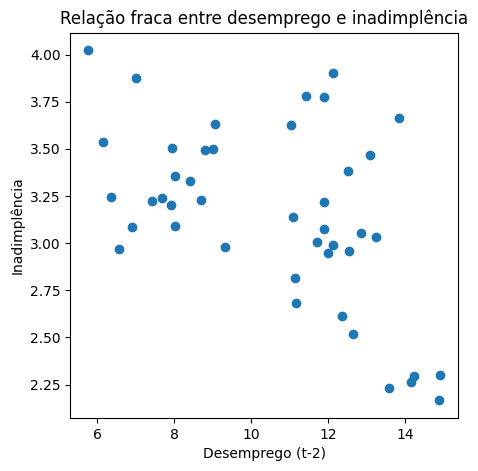

In [156]:
plt.figure(figsize=(5, 5))
plt.scatter(df['taxa_desocupados_lag2'], df['media_inadimplencia'])
plt.xlabel("Desemprego (t-2)")
plt.ylabel("Inadimplência")
plt.title("Relação fraca entre desemprego e inadimplência")
plt.show()

**3 - Evolução temporal das variáveis**  
As variáveis se movem juntas ao longo do tempo, mas com atrasos

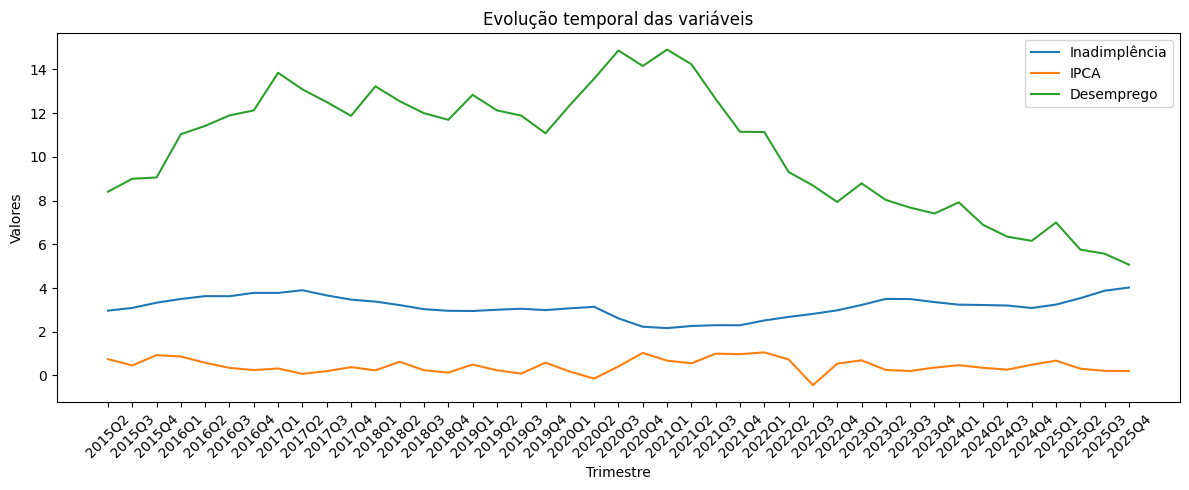

In [157]:
plt.figure(figsize=(12,5))

plt.plot(df['trimestre'], df['media_inadimplencia'], label='Inadimplência')
plt.plot(df['trimestre'], df['media_ipca'], label='IPCA')
plt.plot(df['trimestre'], df['taxa_desocupados'], label='Desemprego')

plt.legend()
plt.title("Evolução temporal das variáveis")
plt.xlabel("Trimestre")
plt.ylabel("Valores")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Fazendo previsões com ARIMA

In [158]:
df = cd_final_trimestral.copy()
df.index = pd.PeriodIndex(df['trimestre'], freq='Q').to_timestamp(how='start')
df = df.drop(columns='trimestre').sort_index()
df = df.asfreq('QS')

def prever_arima(df, col, order=(1,0,0), passos=4):
    serie = df[col]

    modelo = ARIMA(serie, order=order)
    modelo_fit = modelo.fit()

    previsao = modelo_fit.forecast(steps=passos)

    print(f"\n📊 {col}")
    print(modelo_fit.summary())

    return previsao, modelo_fit

def gerar_proximos_trimestres(df, passos=4):
    ultimo = df.index[-1]
    return pd.date_range(start=ultimo, periods=passos + 1, freq='QS')[1:]

def plot_arima(df, col, previsao, trimestres_futuros):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df.index,
        y=df[col],
        mode='lines+markers',
        name='Histórico'
    ))

    fig.add_trace(go.Scatter(
        x=trimestres_futuros,
        y=previsao,
        mode='lines+markers',
        name='Previsão ARIMA',
        line=dict(dash='dash')
    ))

    fig.update_layout(
        title=f'ARIMA - {col}',
        xaxis_title='Trimestre',
        yaxis_title=col,
        hovermode='x unified'
    )

    fig.show()

passos = 4

prev_inad, modelo_inad = prever_arima(df, 'media_inadimplencia', order=(2,1,0), passos=passos)
prev_desemp, modelo_desemp = prever_arima(df, 'taxa_desocupados', order=(2,1,1), passos=passos)
prev_pib, modelo_pib = prever_arima(df, 'txa_variacao_pib', order=(0,1,1), passos=passos)
prev_ipca, modelo_ipca = prever_arima(df, 'media_ipca', order=(1,0,1), passos=passos)

trimestres_futuros = gerar_proximos_trimestres(df, passos=passos)

plot_arima(df, 'media_inadimplencia', prev_inad, trimestres_futuros)
plot_arima(df, 'taxa_desocupados', prev_desemp, trimestres_futuros)
plot_arima(df, 'txa_variacao_pib', prev_pib, trimestres_futuros)
plot_arima(df, 'media_ipca', prev_ipca, trimestres_futuros)


📊 media_inadimplencia
                                SARIMAX Results                                
Dep. Variable:     media_inadimplencia   No. Observations:                   45
Model:                  ARIMA(2, 1, 0)   Log Likelihood                  23.401
Date:                 Tue, 31 Mar 2026   AIC                            -40.801
Time:                         00:08:49   BIC                            -35.448
Sample:                     10-01-2014   HQIC                           -38.816
                          - 10-01-2025                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6665      0.236      2.826      0.005       0.204       1.129
ar.L2         -0.1809      0.241     -0.751      0.452      -0.653       0.291
sigma2         0.0200

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




📊 taxa_desocupados
                               SARIMAX Results                                
Dep. Variable:       taxa_desocupados   No. Observations:                   45
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 -49.799
Date:                Tue, 31 Mar 2026   AIC                            107.598
Time:                        00:08:50   BIC                            114.735
Sample:                    10-01-2014   HQIC                           110.245
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5653      0.219     -2.580      0.010      -0.995      -0.136
ar.L2          0.4347      0.217      2.007      0.045       0.010       0.859
ma.L1          0.9981      4.759

# Conclusão sobre a fase preditiva:  
A aplicação de modelos ARIMA às séries analisadas permitiu aprofundar a compreensão da dinâmica temporal de cada variável, evidenciando diferenças relevantes em seus padrões de comportamento e previsibilidade.

Os resultados indicam que a inadimplência apresenta forte persistência temporal, sendo bem modelada por um processo autoregressivo. O termo AR(1) mostrou-se estatisticamente significativo, confirmando que os valores passados exercem influência relevante sobre os valores futuros. Esse comportamento reforça a ideia de que a inadimplência possui dinâmica própria relativamente estável, permitindo previsões mais confiáveis no curto prazo.

Em relação à taxa de desocupação, o modelo identificou componentes autoregressivos significativos, indicando certa dependência temporal. No entanto, a presença de parâmetros não significativos no componente de média móvel sugere instabilidade na especificação do modelo, indicando que, embora exista persistência, a capacidade preditiva é mais limitada e sensível a variações.

A variação do PIB, por sua vez, apresentou comportamento altamente volátil e pouco previsível. Os parâmetros estimados não foram estatisticamente significativos, indicando que a série é predominantemente influenciada por choques e fatores externos não capturados pelo modelo. Isso sugere baixa capacidade de previsão utilizando modelos autoregressivos simples.

Por fim, o IPCA demonstrou um comportamento intermediário, com destaque para a significância do componente de média móvel. Isso indica que a inflação responde mais a choques recentes do que à sua própria trajetória passada, caracterizando um padrão menos persistente e mais sensível a variações externas.

De forma geral, os resultados mostram que modelos baseados em séries temporais são adequados principalmente para variáveis com forte inércia, como a inadimplência. Para variáveis mais voláteis, como PIB e inflação, a capacidade preditiva é limitada, refletindo a complexidade dos fenômenos econômicos e a influência de fatores exógenos.

# Exportar para Dashboard

In [159]:
df_export = df.copy()

# Adicionar previsões da inadimplência
df_prev = pd.DataFrame({
    'trimestre': futuros_dt,
    'media_inadimplencia': prev_inad
})

df_prev = df_prev.set_index('trimestre')

# Concatenar histórico + previsão
df_final = pd.concat([df_export, df_prev])

# Marcar tipo
df_final['tipo'] = ['Histórico'] * len(df_export) + ['Previsão'] * len(df_prev)

In [160]:
df_final.reset_index().to_csv(
    'dados_dashboard.csv',
    index=False,
    decimal='.',
)